# Continuation of an equilibrium solution

2025-11-04. Continue an ODE equilibrium solution using BifurcationKit, compare to DNS

## 0. Preliminaries

In [ ]:
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise
import BifurcationKit as BK

using CloudAtlas

#Display("text/html", "<style>.container { width:100% !important; }</style>")

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

## 1. Construct ODE model, find equilibrium solution.

This repeats some code from notebook `find-ode-eqb.ipynb`.

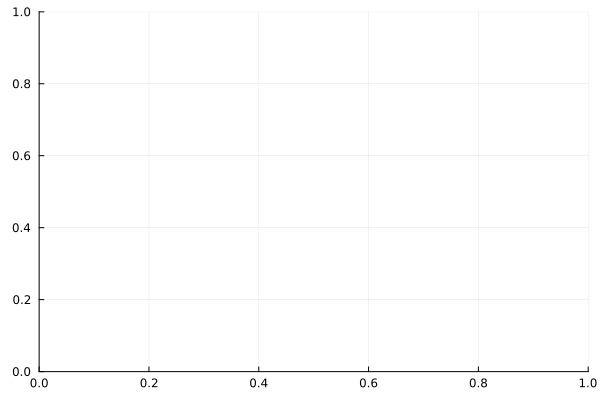

In [2]:
plot()

In [3]:
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 2,2,3  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb

model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

J,K,L,m == 2,2,3,44
(2J+1)(2K+1)(2L+1) + 1 == 176
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 
m = length(model) = 44


Load initial guesses for EQ1 (lower branch) and EQ2 (upper branch) from
files. These are computed by projecting DNS solutions onto the basis, using channelflow. 

In [4]:
xguess = myreaddlm("data/xeq1projection-Re200-2-2-3-44d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc

R = 200
#x = zeros(m)
@show norm(model.f(xguess, R)); #x, R

norm(model.f(xguess, R)) = 0.00991549981572763


Find the ODE representations of the lower and upper branch solutions.

In [5]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  1.053161 seconds (1.80 M allocations: 96.567 MiB, 3.04% gc time, 97.91% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 8.658029169686263e-13


## 2. Continuation of eqbs with BifurcationKit



Compute bifurcation diagram from xeq1 solution.

In [6]:
shear(xeq1, model)

1.7954971498789152

In [7]:
myshear = x -> shear(x,model)
myshear(xeq1)

1.7954971498789152

(J, K, L, m, R) = (2, 2, 3, 44, 200)


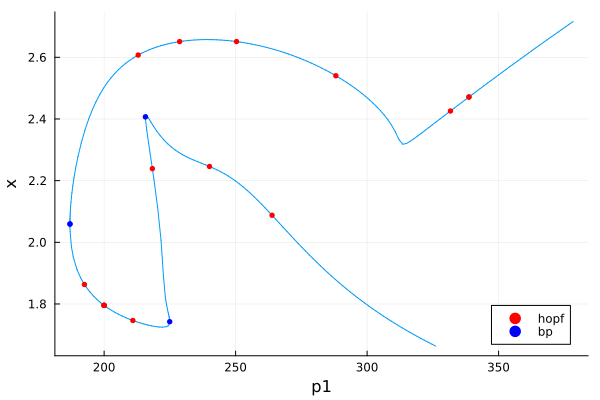

In [8]:
@show J, K, L, m, R

fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, #Ask Gibson why dsmin was set to 1e-07
    max_steps = 200, newton_options = newtopts)

br1 = false
try
    br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)  #Ask Gibson what this does besides throw errors
    plot!(br1)
catch e
    println(e)
end


Compute bifurcation diagram from xeq2 solution. For some reason BifurcationKit doesn't go around the saddle-node bifurcation. I need to learn how to tune the algorithm.

Plot the ODE bifurcation diagram along with the DNS.

163.5222 : 187.01559068553055

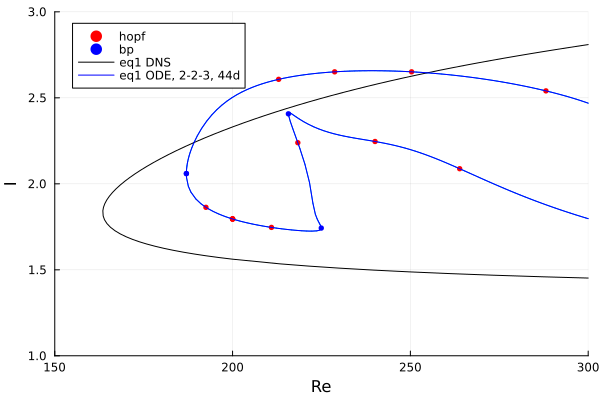

In [9]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
#@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, $J-$K-$L, $(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))

In [10]:
minDNS = false
parameters = []
minimums = []
AYErrors = []
jask = []


Any[]

In [11]:
function DataTable(a, y, r, n, c, fs)#, na, ny)
    #vectorTable = []
    α, γ = a, y                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
    J,K,L = 1,2,3  #1,2,3  #1,1,3      # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
    H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb

    try
        model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
        
        ###@show m = length(model);            # dimension of ODE model
        ##################
        xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc

        R = r
        ###@show norm(model.f(xguess, R));
        ##################
        fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

        ###@show norm(fr(xeq1))/norm(xeq1);
        ##################
        shear(xeq1, model)
        ##################
        myshear = x -> shear(x,model)
        myshear(xeq1)
        ##################
        ###@show J, K, L, m, R

        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(R)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
        )

        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
        contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
            max_steps = 600, newton_options = newtopts)
        ### contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
        ###    max_steps = 200, newton_options = newtopts)

        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

        ###plot!(br1, legendfontsize=fs)
        ##################
        ReD1 = [br1.param br1.x];

        #@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
        #print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
        plot!(ReD1[:,1], ReD1[:,2], color=c, label="", legendfontsize=fs)###"eq$n ODE, $J-$K-$L, $(m)d, $α x $γ", legendfontsize=fs)
        #plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
        plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))
        ##################
        if minimum(ReD1[:,1]) > 1
            push!(parameters, [α, γ])
            push!(minimums, [minimum(ReD1[:,1])])
            #=if (na > size(matrix, 1))
                push!(matrix, [])
            end
            push!(matrix[na], [minimum(ReD1[:,1])])=#
            push!(matrix, minimum(ReD1[:,1]))
        else
            push!(AYErrors, [α, γ, r])
            #=if (na > size(matrix, 1))
                push!(matrix, [])
            end
            push!(matrix[na], [0])=#
            push!(matrix, 0)
        end
        #return [br1, ReD1, c, n, J, K, L, m, α, γ]
        #return [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])]
        #push!(vectorTable, [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])])
        #return vectorTable
    catch e
        push!(AYErrors, [α, γ, r])
        push!(matrix, 0)
    end
end

DataTable (generic function with 1 method)

In [12]:
using Suppressor

parameters = []
minimums = []
AYErrors = []
matrix = []

Any[]

In [ ]:
#α, γ
parameters = []
minimums = []
AYErrors = []
matrix = []
minDNS = 163.5222
initialA = 1.85 #1.85
numOfTestsA = 50
rangeOfChangeInA = 1.75 #1.55
deltaA = rangeOfChangeInA/numOfTestsA
initialY = 1.3 #1.3
numOfTestsY = 37
rangeOfChangeInY = 1.2 #0.9
deltaY = rangeOfChangeInY/numOfTestsY
Re = 200 #This is supposed to be 200 you bone head
fontSize = 5

@suppress begin
    eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
    plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")

    #temp = []
    
    


    

     #α plot collecter
     for i in 0:2*rangeOfChangeInA/deltaA
        for j in 0:2*rangeOfChangeInY/deltaY
            ###DataTable((initialA - rangeOfChangeInA) + i * deltaA, (initialY - rangeOfChangeInY) + j * deltaY, Re, 0,
            ###    RGBA(0 + i * (deltaA/rangeOfChangeInA)/2, 1 - i * (deltaA/rangeOfChangeInA)/2, 0 + j * (deltaY/rangeOfChangeInY)/2, 1), fontSize);
            DataTable((initialA - rangeOfChangeInA) + i * deltaA, (initialY - rangeOfChangeInY) + j * deltaY, Re, 0,
                RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1), fontSize)#, i + 1, j + 1);
            ###display(RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1))
        end
        display(plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5)))
        savefig("α200DataSet2/α_$((initialA - rangeOfChangeInA) + i * deltaA).png")
        plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
    end
    
    
    

    #= #γ plot collecter
    for i in 0:2*rangeOfChangeInY/deltaY
        for j in 0:2*rangeOfChangeInA/deltaA
            DataTable((initialA - rangeOfChangeInA) + j * deltaA, (initialY - rangeOfChangeInY) + i * deltaY, Re, 0,
                RGBA(0 + j * (deltaA/rangeOfChangeInA)/2, 1 - j * (deltaA/rangeOfChangeInA)/2, 0, 1), fontSize);
            ###display(RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1))
        end
        display(plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5)))
        savefig("γ200DataSet2/γ_$((initialY - rangeOfChangeInY) + i * deltaY).png")
        plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
    end
    =#

    
end
#println(minimums)
#println(matrix)


#α plot collecter reshaper : γ is the y axis
show(IOContext(stdout, :limit => false), "text/plain", reshape(matrix, 2 * numOfTestsY + 1, 2 * numOfTestsA + 1))
#display(reshape(matrix, 2 * numOfTestsY + 1, 2 * numOfTestsA + 1))

#γ plot collecter reshaper : α is the y axis
#display(reshape(matrix, 2 * numOfTestsA + 1, 2 * numOfTestsY + 1))

#show(parameters[1][1])
###plot!(xlabel="Re", ylabel="I", xlim=(95,300), ylim=(1,3.5))
#push!(temp, DataTable(1.5, 2.0, 200, 1, :blue))
#temp = DataTable(1.5, 2.0, 200, 1, :blue)
#plot!(temp[1])
#plot!(temp[1][2][:,1], temp[1][2][:,2], color=temp[1][3], label="eq$(temp[1][4]) ODE, $(temp[1][5])-$(temp[1][6])-$(temp[1][7]), $(temp[1][8])d, $(temp[1][9]) x $(temp[1][10])")
#push!(temp, DataTable(1.0, 2.0, 200, 2, :red))
#temp = DataTable(1.0, 2.0, 200, 2, :red)
#plot!(temp[1])
#plot!(temp[2][2][:,1], temp[2][2][:,2], color=temp[2][3], label="eq$(temp[2][4]) ODE, $(temp[2][5])-$(temp[2][6])-$(temp[2][7]), $(temp[2][8])d, $(temp[2][9]) x $(temp[2][10])")
#plot!(temp[1][2][:,1], temp[1][2][:,2], color=temp[1][3], label="eq$(temp[1][4]) ODE, $(temp[1][5])-$(temp[1][6])-$(temp[1][7]), $(temp[1][8])d, $(temp[1][9]) x $(temp[1][10])")
#plot!(temp[2][2][:,1], temp[2][2][:,2], color=temp[2][3], label="eq$(temp[2][4]) ODE, $(temp[2][5])-$(temp[2][6])-$(temp[2][7]), $(temp[2][8])d, $(temp[2][9]) x $(temp[2][10])")

In [68]:
matrix = zeros(2,2)
matrixMutate(1,1,1,matrix)
show(matrix)

[1.0 0.0; 0.0 0.0]

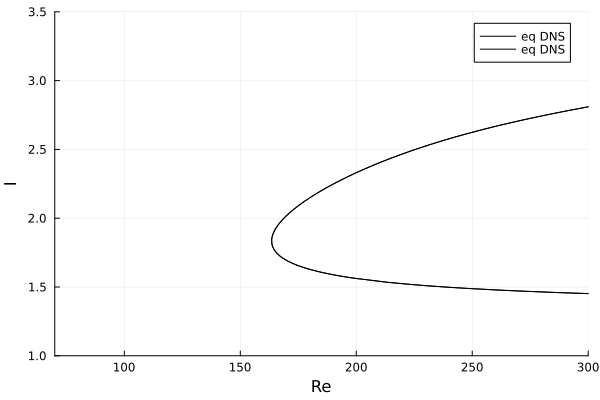

In [200]:
eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5))

In [ ]:
#savefig("testing/my_plot4.png")

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks\\testing\\my_plot4.png"

In [21]:
println("MinDNS : ", minDNS)
println("Parameters [α, γ] : ", parameters)
println("MinsOfODEs : ", minimums)
println("Error Parameters : ", AYErrors)
if length(minimums) != 0
    minIndex = findmin(minimums)[2]
    minValue = findmin(minimums)[1]
    println("Index Of Min Value : ", minIndex, ", Min Value : ", minValue, ", Parameters Of Min Value [α, γ] : [", parameters[minIndex][1], ", ", parameters[minIndex][2], "]")
end

UndefVarError: UndefVarError: `minDNS` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [59]:
for i in 1:length(minimums)
    println("Data [α, γ], Min : ", parameters[i], ", ", minimums[i])
end

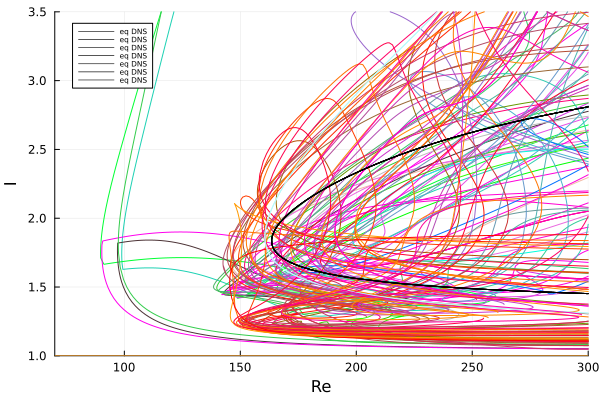

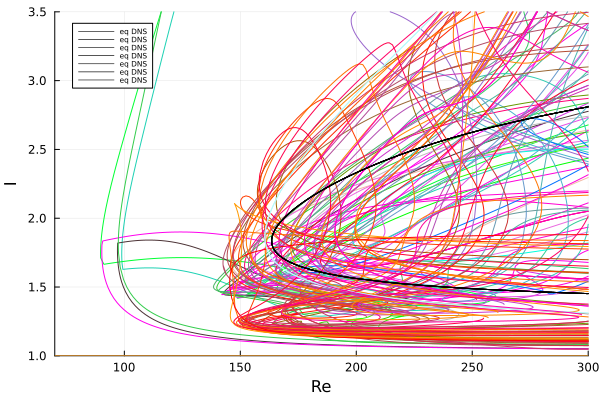

In [193]:
display(plot!())
display(plot!())